In [7]:
!pip install ultralytics opencv-python-headless matplotlib

# Kaggle API token upload karne ka prompt
from google.colab import files
import os

print("Apna kaggle.json file upload karein:")
files.upload()

# Kaggle directory setup aur dataset download
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d farzadnekouei/top-view-vehicle-detection-image-dataset
!unzip -q top-view-vehicle-detection-image-dataset.zip -d dataset/

Apna kaggle.json file upload karein:


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/farzadnekouei/top-view-vehicle-detection-image-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 45.6M/45.6M [00:04<00:00, 11.6MB/s]



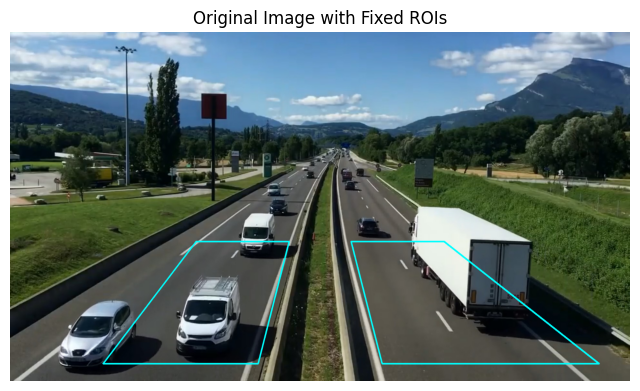

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import time
import glob

# Load YOLOv8n
model = YOLO('yolov8n.pt')

# Load the first image from the dataset
image_paths = glob.glob("dataset/**/*.jpg", recursive=True)
test_image_path = image_paths[0]
original_img = cv2.imread(test_image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Get dynamic image dimensions
h, w = original_img.shape[:2]

# Roll Number Custom Threshold
custom_threshold = 883

# DYNAMIC ROIs: Forces the boxes onto the bottom 40% of the image (the road)
rois = [
    # Slot 1 (Left Highway Lanes)
    np.array([
        [int(w * 0.30), int(h * 0.60)], # Top-left
        [int(w * 0.45), int(h * 0.60)], # Top-right
        [int(w * 0.40), int(h * 0.95)], # Bottom-right
        [int(w * 0.15), int(h * 0.95)]  # Bottom-left
    ], np.int32),

    # Slot 2 (Right Highway Lanes)
    np.array([
        [int(w * 0.55), int(h * 0.60)], # Top-left
        [int(w * 0.70), int(h * 0.60)], # Top-right
        [int(w * 0.95), int(h * 0.95)], # Bottom-right
        [int(w * 0.60), int(h * 0.95)]  # Bottom-left
    ], np.int32)
]

def show_img(title, img, cmap=None):
    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

# Display Original with ROIs
temp_img = original_img.copy()
cv2.polylines(temp_img, rois, True, (0, 255, 255), 4) # Thickened the lines to 4 so they are clearly visible
show_img("Original Image with Fixed ROIs", temp_img)

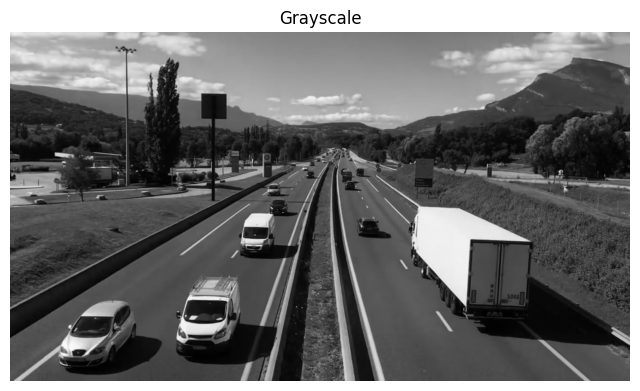

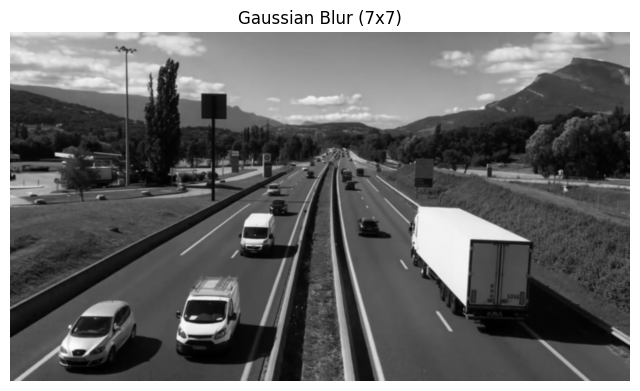

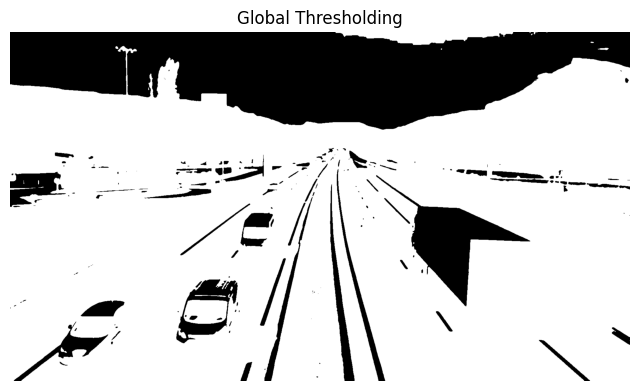

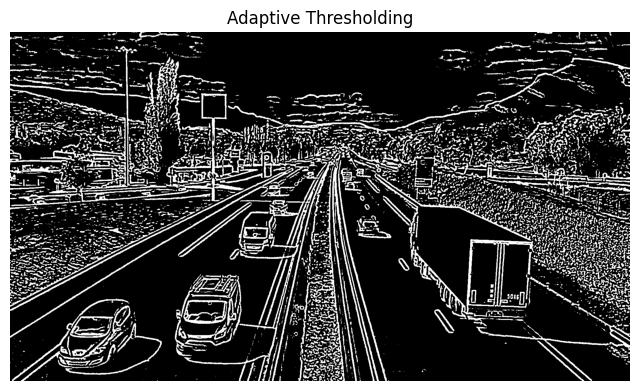

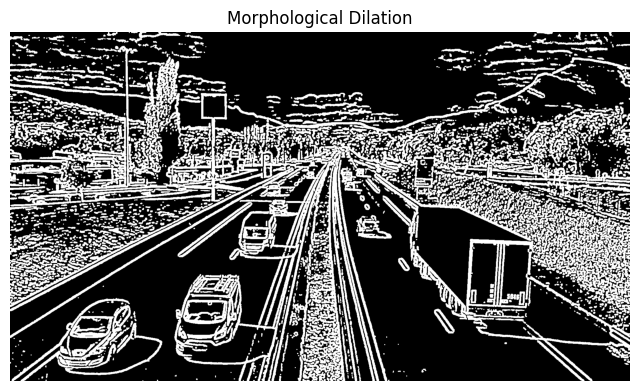

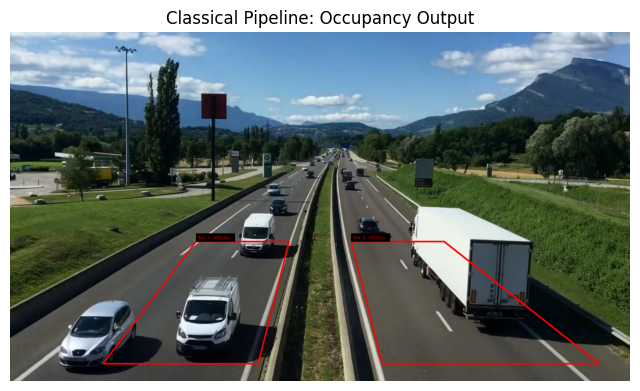

In [19]:
# 1. Grayscale
gray = cv2.cvtColor(original_img, cv2.COLOR_RGB2GRAY)
show_img("Grayscale", gray, cmap='gray')

# 2. Gaussian Blur (7x7)
blurred = cv2.GaussianBlur(gray, (7, 7), 0)
show_img("Gaussian Blur (7x7)", blurred, cmap='gray')

# 3. Thresholding Comparison
_, global_thresh = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY_INV)
show_img("Global Thresholding", global_thresh, cmap='gray')

adaptive_thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY_INV, 11, 2)
show_img("Adaptive Thresholding", adaptive_thresh, cmap='gray')

# 4. Morphological Dilation
kernel = np.ones((3,3), np.uint8)
dilated = cv2.dilate(adaptive_thresh, kernel, iterations=1)
show_img("Morphological Dilation", dilated, cmap='gray')

# 5. Pixel Counting & Occupancy Classification
classical_output = original_img.copy()
for i, roi in enumerate(rois):
    mask = np.zeros_like(gray)
    cv2.fillPoly(mask, [roi], 255)
    roi_pixels = cv2.bitwise_and(dilated, dilated, mask=mask)

    pixel_count = cv2.countNonZero(roi_pixels)

    # Classification using Roll Number Threshold (883)
    status = "Occupied" if pixel_count > custom_threshold else "Free"
    color = (255, 0, 0) if status == "Occupied" else (0, 255, 0) # Red = Occupied, Green = Free

    cv2.polylines(classical_output, [roi], True, color, 3)
    # Add dark background for text readability
    cv2.rectangle(classical_output, (roi[0][0], roi[0][1]-25), (roi[0][0]+120, roi[0][1]), (0,0,0), -1)
    cv2.putText(classical_output, f"Slot {i+1}: {pixel_count}px", (roi[0][0]+5, roi[0][1]-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

show_img("Classical Pipeline: Occupancy Output", classical_output)


image 1/1 /content/dataset/Vehicle_Detection_Image_Dataset/sample_image.jpg: 384x640 9 cars, 79.0ms
Speed: 2.2ms preprocess, 79.0ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


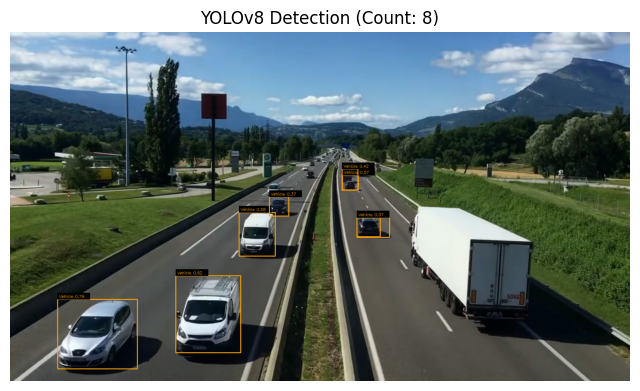

In [20]:
yolo_output = original_img.copy()

results = model(test_image_path)
detections = results[0].boxes

vehicle_classes = [2, 3, 5, 7] # car, motorcycle, bus, truck
vehicle_count = 0

for box in detections:
    cls = int(box.cls[0])
    conf = float(box.conf[0])

    if cls in vehicle_classes and conf > 0.35:
        vehicle_count += 1
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(yolo_output, (x1, y1), (x2, y2), (255, 165, 0), 2)
        cv2.rectangle(yolo_output, (x1, y1-20), (x1+100, y1), (0,0,0), -1)
        cv2.putText(yolo_output, f"Vehicle {conf:.2f}", (x1+5, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 165, 0), 1)

show_img(f"YOLOv8 Detection (Count: {vehicle_count})", yolo_output)

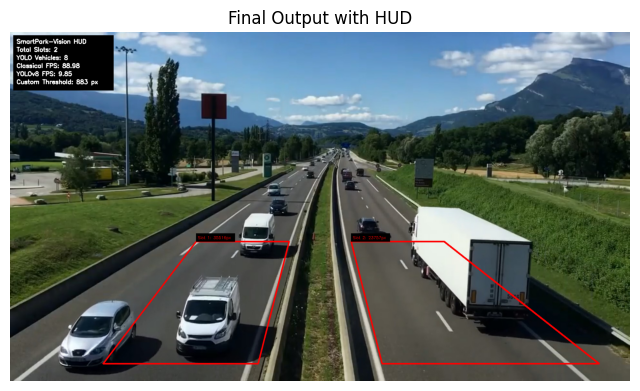

Recorded Classical FPS: 88.98
Recorded YOLO FPS: 9.85


In [21]:
# Benchmarking Classical
start_time = time.time()
for _ in range(10):
    _b = cv2.GaussianBlur(gray, (7,7), 0)
    _t = cv2.adaptiveThreshold(_b, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
    _d = cv2.dilate(_t, kernel, iterations=1)
classical_fps = 10 / (time.time() - start_time)

# Benchmarking YOLO
start_time = time.time()
for _ in range(10):
    _ = model(test_image_path, verbose=False)
yolo_fps = 10 / (time.time() - start_time)

# Final HUD
final_hud = classical_output.copy()
hud_text = [
    "SmartPark-Vision HUD",
    f"Total Slots: {len(rois)}",
    f"YOLO Vehicles: {vehicle_count}",
    f"Classical FPS: {classical_fps:.2f}",
    f"YOLOv8 FPS: {yolo_fps:.2f}",
    f"Custom Threshold: {custom_threshold} px"
]

# Black background block for HUD
cv2.rectangle(final_hud, (10, 10), (320, 180), (0, 0, 0), -1)

y_offset = 35
for text in hud_text:
    cv2.putText(final_hud, text, (20, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    y_offset += 25

show_img("Final Output with HUD", final_hud)

print(f"Recorded Classical FPS: {classical_fps:.2f}")
print(f"Recorded YOLO FPS: {yolo_fps:.2f}")